# Numeric Pattern Dataset Using Supervised and Unsupervised Learning


## Task 1 - Dataset Loading

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../Data/numeric_pattern.csv")
# Check shape
print("Shape:", df.shape) 
# Display first records
df.head()

Shape: (10000, 13)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Target
0,15.093999,-1.302327,21.641503,-8.395353,-27.740554,25.504038,8.322571,11.795655,17.073258,-7.938496,3.231336,6.127388,99.138848
1,16.141720,-5.279374,14.865296,-4.677093,-22.399914,18.500436,2.958703,4.680822,21.484486,-1.845518,3.200518,6.537896,83.264162
2,0.206033,2.021703,6.890110,3.231378,-15.390483,16.109193,-0.366016,4.978612,21.511358,-16.008626,3.006648,7.210659,20.910641
3,3.781895,-13.829421,7.446637,0.533582,-22.741895,19.841599,10.743387,13.589657,24.811011,-2.714167,-4.180635,4.024636,63.124500
4,11.662774,-14.423611,21.813357,-2.547716,-16.684583,26.899445,-3.054589,-1.304038,18.351102,-3.039066,-0.994683,7.173266,115.609377


In [2]:
# Display Last records
df.tail()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Target
9995,11.428050,0.498952,15.500402,4.042926,-24.974303,14.914774,5.332682,9.359254,19.879359,-1.096487,0.876663,7.446253,80.893387
9996,17.156738,-14.257971,5.255468,-7.231702,-28.081954,18.065662,17.994481,11.230152,22.834857,-9.063624,0.062606,1.340094,75.937029
9997,9.950551,-0.979114,10.232229,-2.857155,-36.099625,25.066853,0.360007,12.508923,18.718846,-5.035328,-5.436517,1.525163,63.274122
9998,11.929710,-5.923325,13.948293,4.525815,-25.178880,20.725596,-3.171923,0.046972,23.180961,-2.757088,-4.177816,10.569090,91.183014
9999,15.913336,-8.745749,12.546825,2.973466,-17.879238,12.136076,1.126482,5.600872,19.082835,-9.464784,0.406196,2.265144,90.661936


In [3]:
#Dataset information 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Feature_1   10000 non-null  float64
 1   Feature_2   10000 non-null  float64
 2   Feature_3   10000 non-null  float64
 3   Feature_4   10000 non-null  float64
 4   Feature_5   10000 non-null  float64
 5   Feature_6   10000 non-null  float64
 6   Feature_7   10000 non-null  float64
 7   Feature_8   10000 non-null  float64
 8   Feature_9   10000 non-null  float64
 9   Feature_10  10000 non-null  float64
 10  Feature_11  10000 non-null  float64
 11  Feature_12  10000 non-null  float64
 12  Target      10000 non-null  float64
dtypes: float64(13)
memory usage: 1015.8 KB


In [4]:
# Statistical summary 
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,Target
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,10.902752,-5.515442,15.985474,3.282728,-18.781350,18.837356,8.886323,10.638008,18.918821,-3.848551,-0.043408,4.574454,86.107060
std,5.545864,5.224133,7.911146,4.768569,6.269684,5.666990,8.325059,6.952668,2.672671,8.560132,4.201599,2.704342,29.266005
min,-13.230289,-25.871096,-11.970034,-16.868400,-42.646928,-3.290564,-20.223606,-16.276264,9.617995,-36.209418,-14.061798,-5.684898,-23.931628
25%,7.226938,-9.072457,10.648660,0.109466,-23.002438,15.077808,3.272696,6.008569,17.115158,-9.724697,-2.854215,2.744483,66.177163
50%,10.886460,-5.574947,16.013633,3.261242,-18.837410,18.831686,8.828605,10.546496,18.912655,-3.874499,-0.071262,4.548499,86.385063
75%,14.542256,-1.999012,21.271198,6.468758,-14.564689,22.596417,14.502743,15.301074,20.731311,2.000178,2.772635,6.385990,106.083026
max,33.144669,16.001117,44.918097,23.831603,12.880772,42.593450,38.777982,38.726437,28.800483,34.752790,16.932750,14.778993,188.628509


In [5]:
# Missing value analysis
missing = df.isnull().sum()
pd.DataFrame({"Missing Count": missing}).sort_values("Missing Count")

,Missing Count
Feature_1,0
Feature_2,0
Feature_3,0
Feature_4,0
Feature_5,0
Feature_6,0
Feature_7,0
Feature_8,0
Feature_9,0
Feature_10,0


## Task 2 - Exploratory Data Analysis

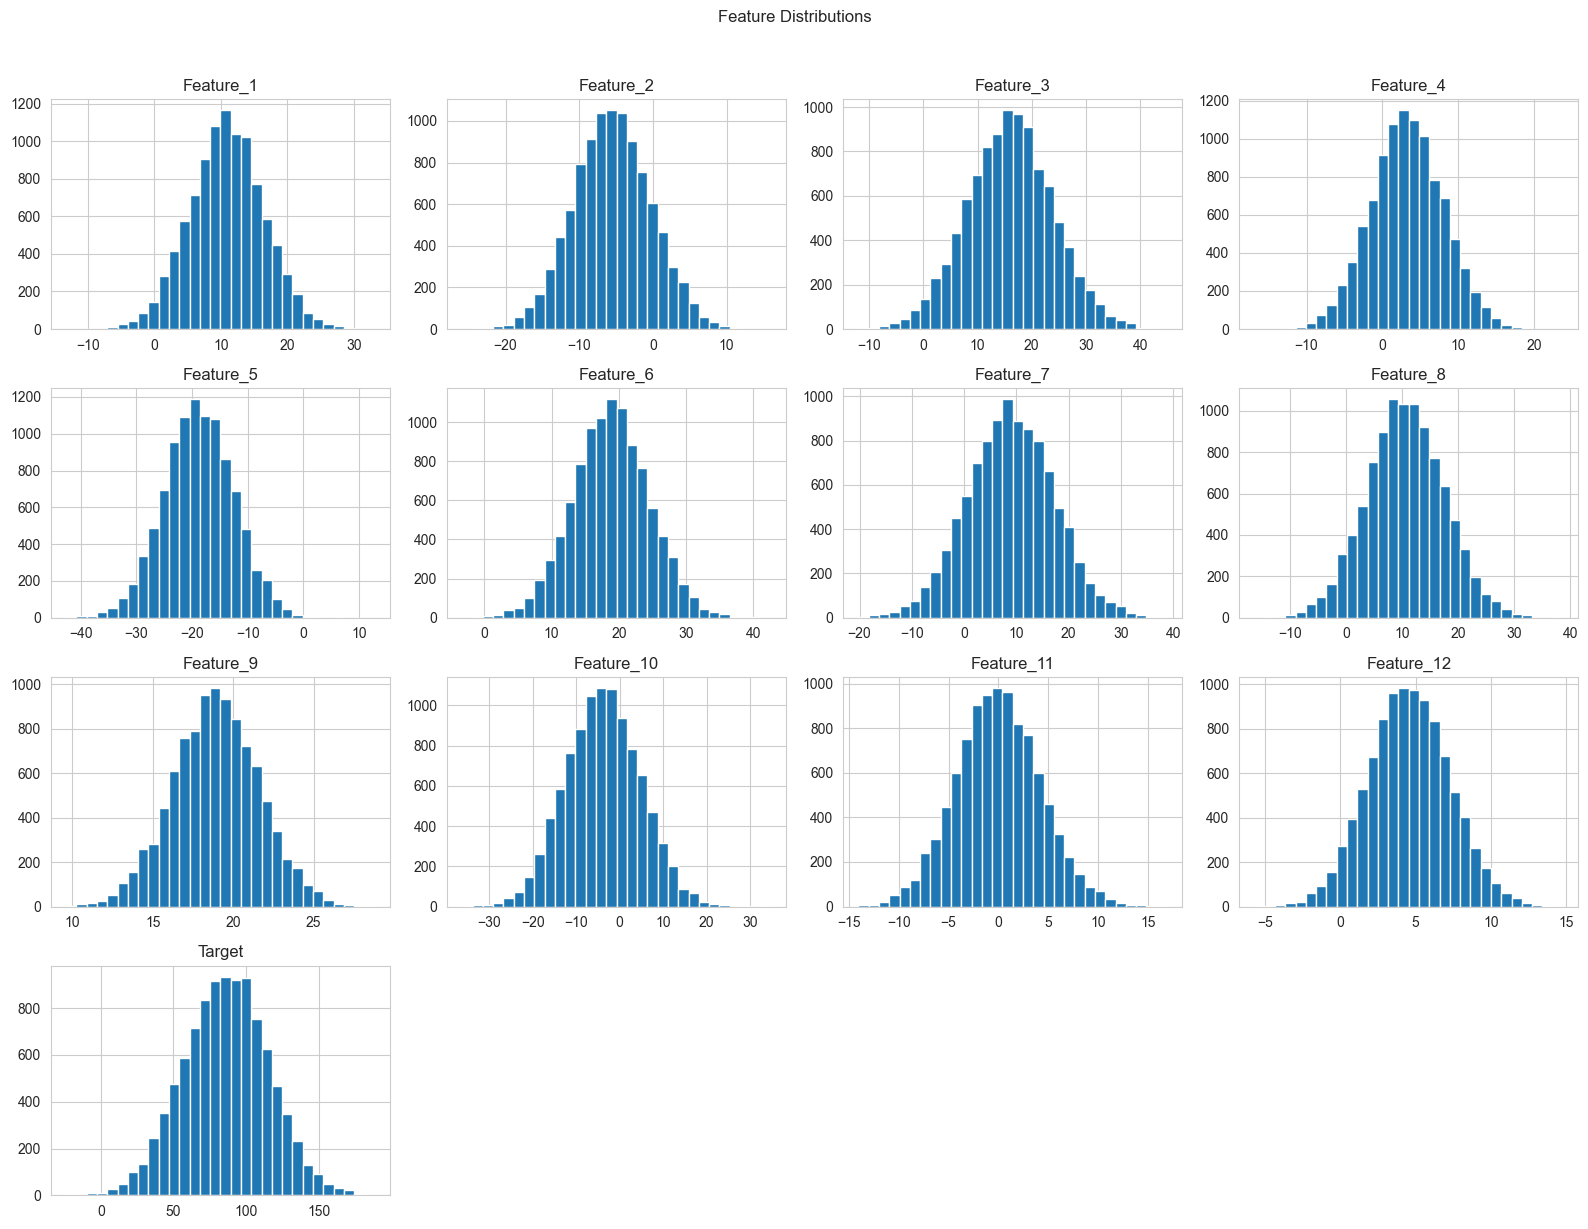

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
df.hist(figsize=(16, 12), bins=30)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

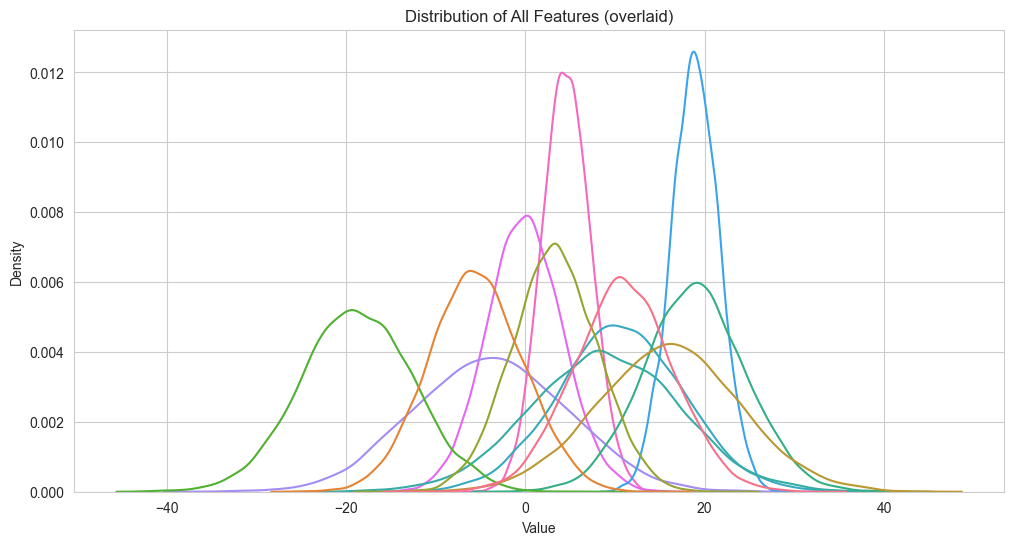

In [7]:
# Distribution plots - all features overlaid on one plot
new_df = df.drop(columns="Target").melt(var_name="Feature", value_name="Value")
plt.figure(figsize=(12, 6))
sns.kdeplot(data=new_df, x="Value", hue="Feature", legend=False)
plt.title("Distribution of All Features (overlaid)")
plt.show()

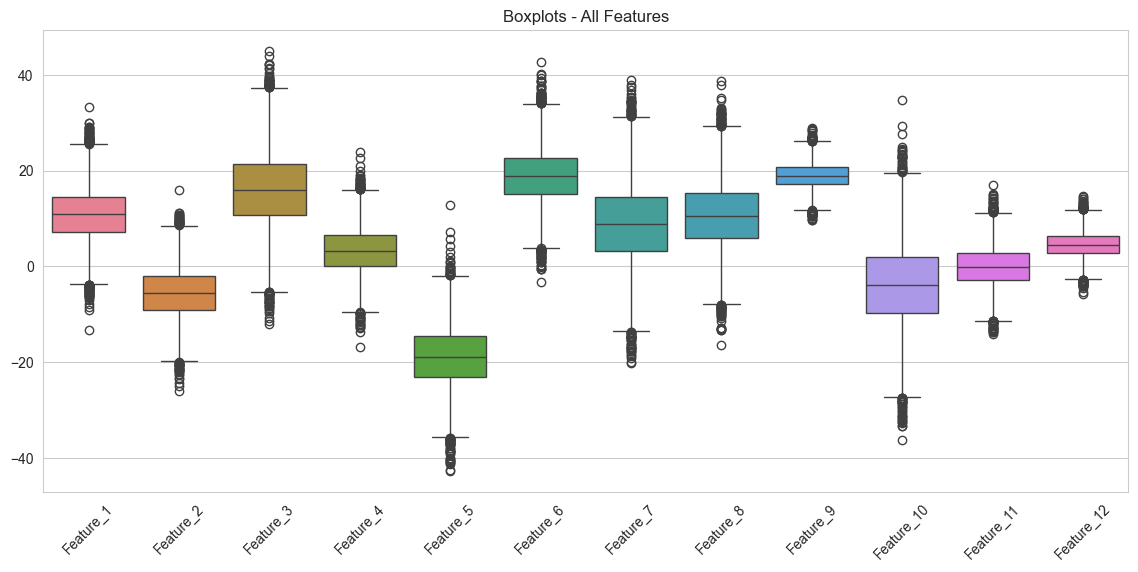

In [8]:
# Boxplots - all features in a single plot for quick outlier scan
plt.figure(figsize=(14, 6))
sns.boxplot(data=df.drop(columns="Target"))
plt.xticks(rotation=45)
plt.title("Boxplots - All Features")
plt.show()

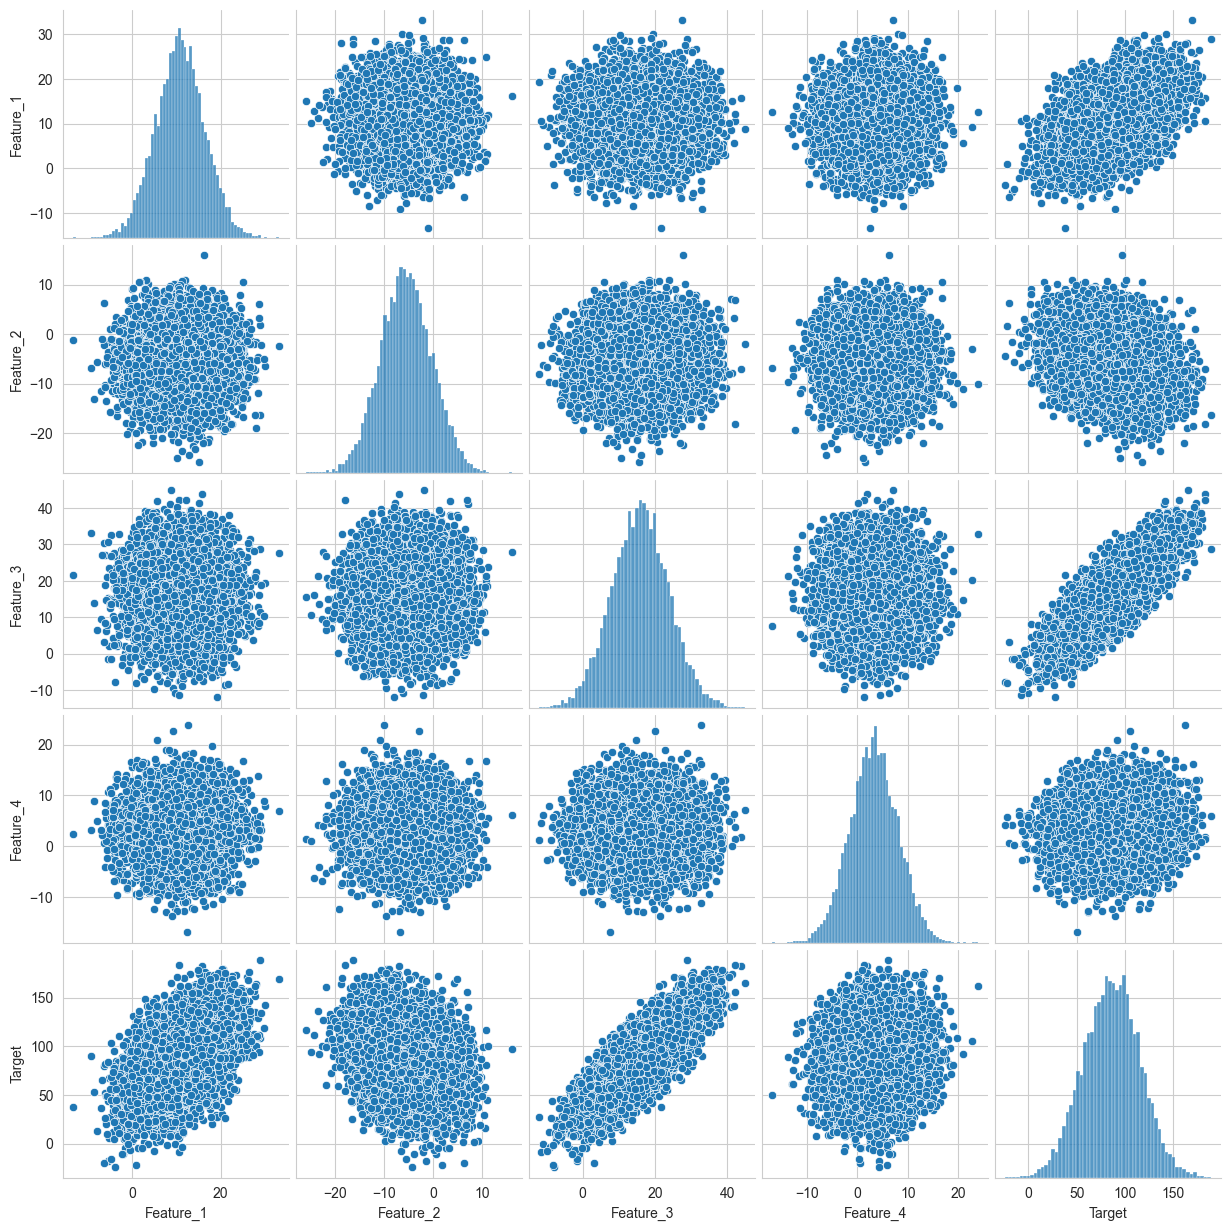

In [9]:
# Pairplot on a subset of features (full 13-column pairplot is heavy)
sample_cols = ["Feature_1", "Feature_2", "Feature_3", "Feature_4", "Target"]
sns.pairplot(df[sample_cols].dropna())
plt.show()

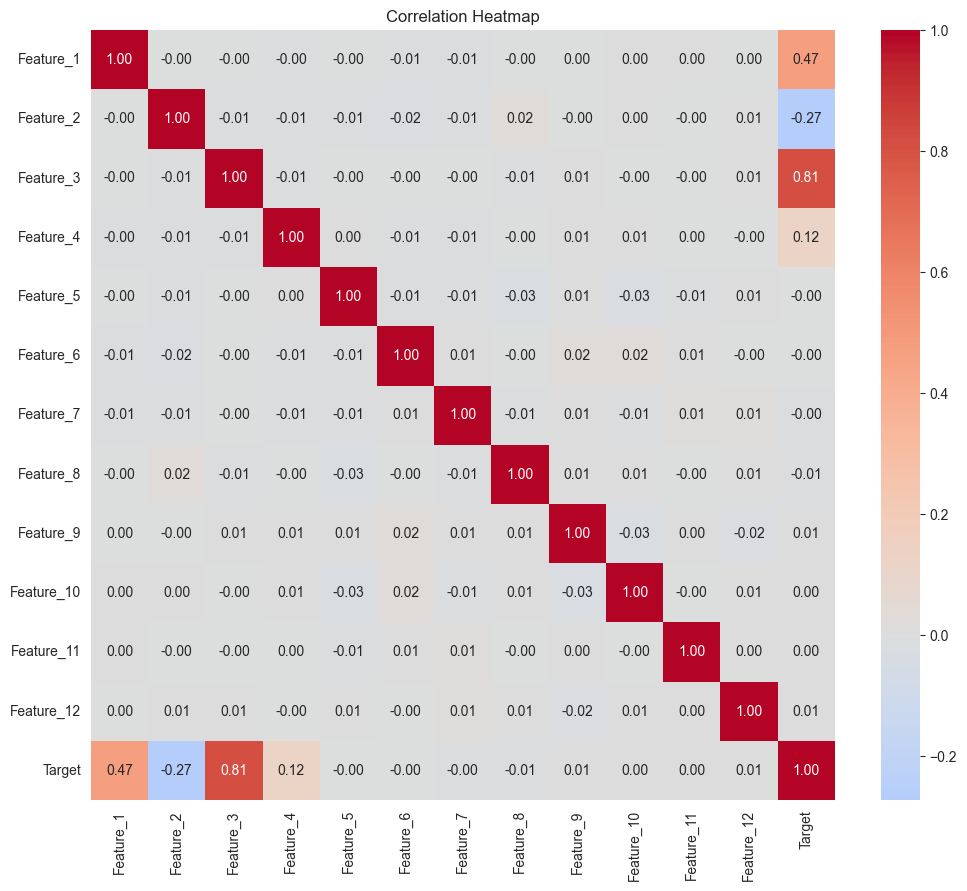

In [10]:
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## Task 3 - Data Cleaning

In [11]:
# Missing value handling
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining missing values:", df_clean.isnull().sum().sum())

Remaining missing values: 0


In [12]:
# Duplicate removal
duplicate = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Duplicates found and removed: {duplicate}")
print("Shape after dedup:", df_clean.shape)

Duplicates found and removed: 0
Shape after dedup: (10000, 13)


In [13]:
# Outlier detection using IQR method
feature_cols = [c for c in df_clean.columns if c != "Target"]

Q1 = df_clean[feature_cols].quantile(0.25)
Q3 = df_clean[feature_cols].quantile(0.75)
IQR = Q3 - Q1

is_outlier = (df_clean[feature_cols] < (Q1 - 1.5 * IQR)) | (df_clean[feature_cols] > (Q3 + 1.5 * IQR))
is_outlier.sum().sort_values(ascending=False)

Feature_6     99
Feature_1     95
Feature_8     77
Feature_3     75
Feature_7     75
Feature_11    73
Feature_12    72
Feature_5     70
Feature_9     64
Feature_4     64
Feature_10    63
Feature_2     55
dtype: int64

In [14]:
# Outlier treatment - capping at IQR bounds
df_treated = df_clean.copy()
for col in feature_cols:
    Q1 = df_treated[col].quantile(0.25)
    Q3 = df_treated[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_treated[col] = df_treated[col].clip(lower=lower, upper=upper)

print("Outlier treatment (capping) applied.")

Outlier treatment (capping) applied.


## Task 4 - Feature Engineering (Scaling)

In [15]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X = df_treated[feature_cols]
y = df_treated["Target"]

standard_scaler = StandardScaler()
X_standard = pd.DataFrame(standard_scaler.fit_transform(X), columns=feature_cols)

minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(minmax_scaler.fit_transform(X), columns=feature_cols)

print("StandardScaler result (mean~0, std~1):")
print(X_standard.describe().loc[["mean", "std"]])
print()
print("MinMaxScaler result (range 0-1):")
print(X_minmax.describe().loc[["min", "max"]])

StandardScaler result (mean~0, std~1):
         Feature_1     Feature_2     Feature_3     Feature_4     Feature_5  \
mean  9.947598e-18  4.831691e-17  2.984279e-17  1.776357e-17  4.604317e-16   
std   1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00   

         Feature_6     Feature_7     Feature_8     Feature_9    Feature_10  \
mean  2.131628e-18 -3.765876e-17 -1.886491e-16 -6.131984e-16  9.947598e-18   
std   1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00  1.000050e+00   

        Feature_11    Feature_12  
mean -9.237056e-18 -5.400125e-17  
std   1.000050e+00  1.000050e+00  

MinMaxScaler result (range 0-1):
     Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
min        0.0        0.0        0.0        0.0        0.0        0.0   
max        1.0        1.0        1.0        1.0        1.0        1.0   

     Feature_7  Feature_8  Feature_9  Feature_10  Feature_11  Feature_12  
min        0.0        0.0        0.0         0.0         

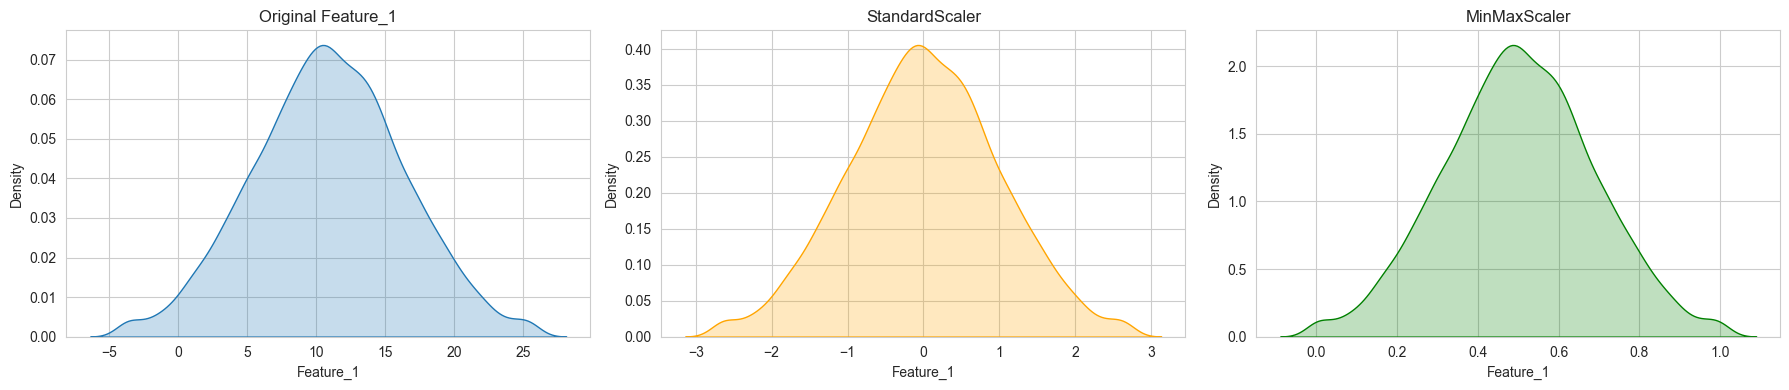

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.kdeplot(X["Feature_1"], ax=axes[0], fill=True)
axes[0].set_title("Original Feature_1")
sns.kdeplot(X_standard["Feature_1"], ax=axes[1], fill=True, color="orange")
axes[1].set_title("StandardScaler")
sns.kdeplot(X_minmax["Feature_1"], ax=axes[2], fill=True, color="green")
axes[2].set_title("MinMaxScaler")
plt.tight_layout()
plt.show()

## Task 5 - Feature Selection

In [17]:
# Correlation Analysis - drop features highly correlated with each other (> 0.9)
corr_matrix = X_standard.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]
print("Features flagged for high correlation (>0.9):", to_drop_corr if to_drop_corr else "None found")

Features flagged for high correlation (>0.9): None found


In [18]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=0.01)
vt.fit(X_standard)
low_variance_cols = X_standard.columns[~vt.get_support()].tolist()
print("Low variance features (threshold 0.01):", low_variance_cols if low_variance_cols else "None found")

Low variance features (threshold 0.01): None found


In [19]:
# Final feature set carried forward to all engineer sections
X_selected = X_standard.copy()
print("Final feature set shape:", X_selected.shape)
X_selected.head()

Final feature set shape: (10000, 12)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12
0,0.762185,0.810382,0.718826,-2.466006,-1.442080,1.188260,-0.068336,0.167905,-0.694674,-0.480802,0.784958,0.577927
1,0.952690,0.045052,-0.142307,-1.680785,-0.582782,-0.059537,-0.716766,-0.862622,0.965428,0.235762,0.777577,0.730679
2,-1.944870,1.450048,-1.155808,-0.010677,0.545020,-0.485573,-1.118687,-0.819490,0.975541,-1.429889,0.731145,0.981017
3,-1.294677,-1.600293,-1.085083,-0.580397,-0.637806,0.179411,0.224313,0.427752,2.217318,0.133604,-0.990232,-0.204516
4,0.138291,-1.714637,0.740665,-1.231104,0.336802,1.436873,-1.443705,-1.729482,-0.213776,0.095395,-0.227186,0.967103


##  Supervised Learning (Regression) + K-Means Clustering

### Regression - Train/Test Split

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (8000, 12)  Test shape: (2000, 12)


In [21]:
# rain Models: Linear Regression, Decision Tree, Random Forest
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=200),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

print("Models trained:", list(models.keys()))

Models trained: ['Linear Regression', 'Decision Tree', 'Random Forest']


In [22]:
# Evaluation - MAE, RMSE, R2
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

results = []
for name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)  
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3.918294,4.919799,0.972319
1,Decision Tree,7.357972,9.303473,0.901014
2,Random Forest,4.801181,6.130144,0.957024


### Visualization - Actual vs Predicted

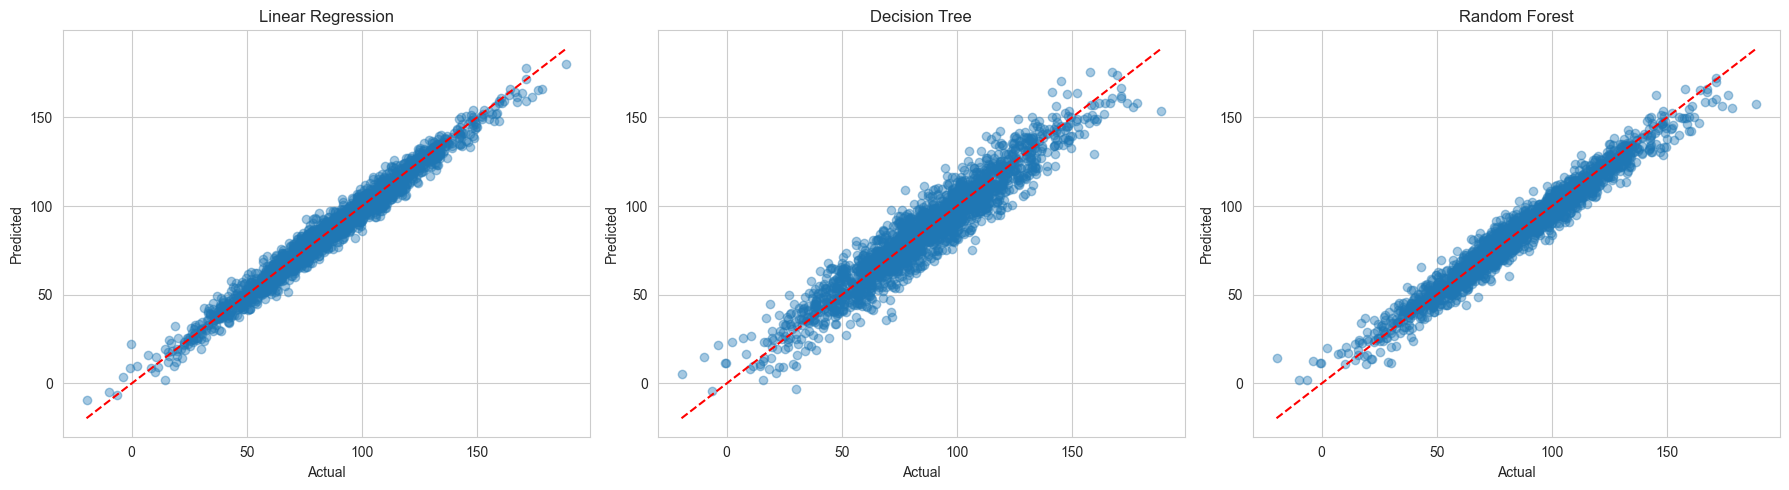

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.4)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Visualization - Residual Plot

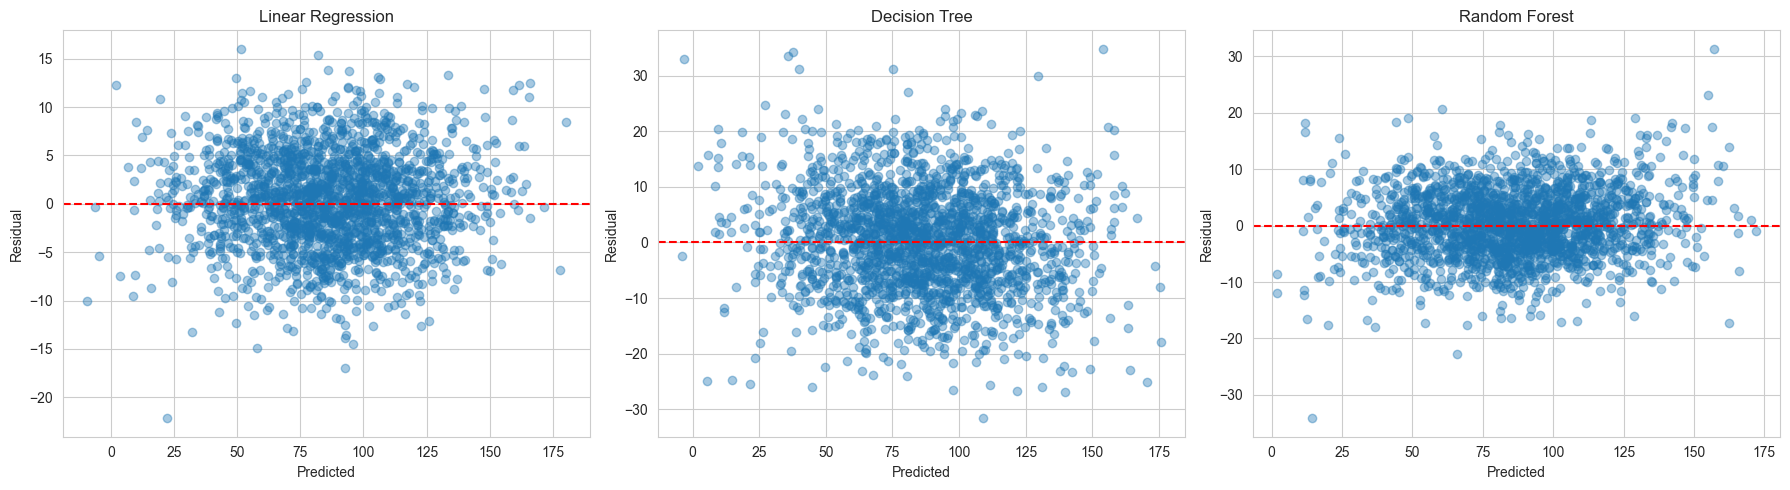

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.4)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Visualization - Feature Importance 

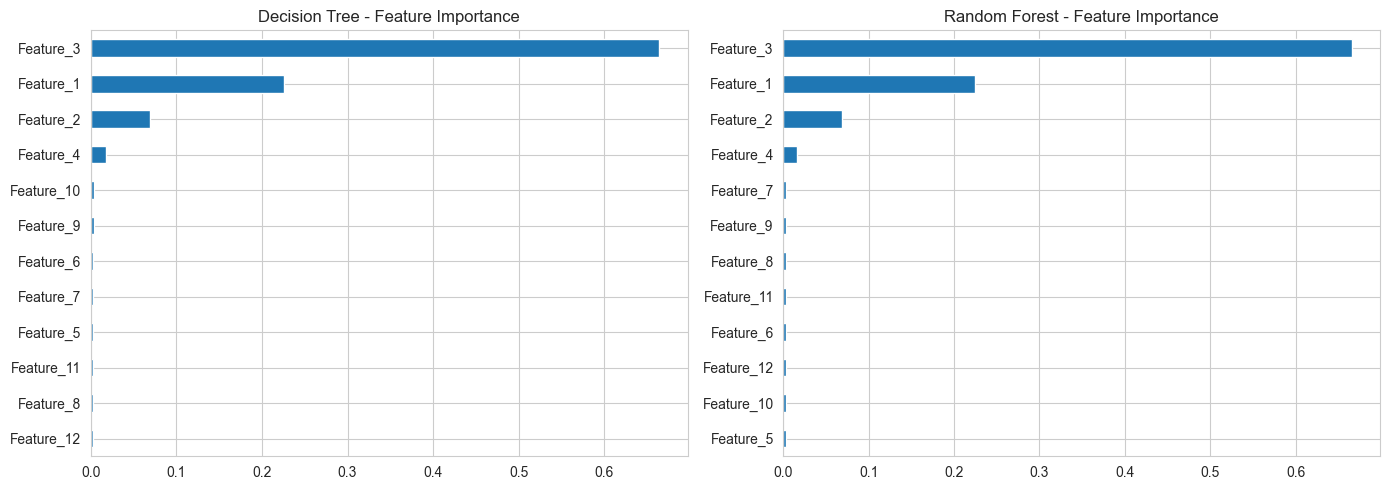

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["Decision Tree", "Random Forest"]):
    importances = pd.Series(models[name].feature_importances_, index=X_selected.columns)
    importances.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"{name} - Feature Importance")
plt.tight_layout()
plt.show()

### K-Means Clustering 
- Elbow Method 
- Silhouette Score 
- Cluster Visualization 
- PCA Cluster Projection

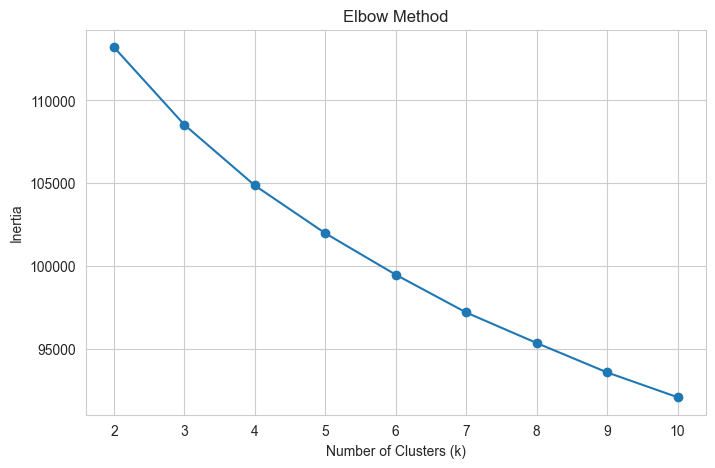

In [26]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_selected)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

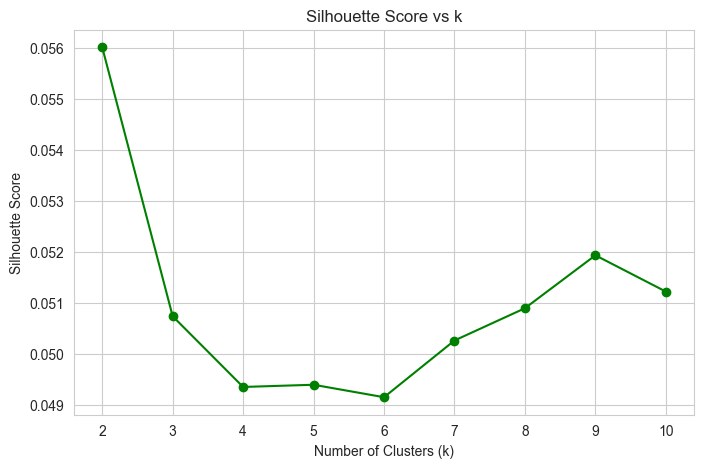

Best k by silhouette score: 2


In [27]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_selected)
    sil_scores.append(silhouette_score(X_selected, labels))

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), sil_scores, marker="o", color="green")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.grid(True)
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Best k by silhouette score: {best_k}")

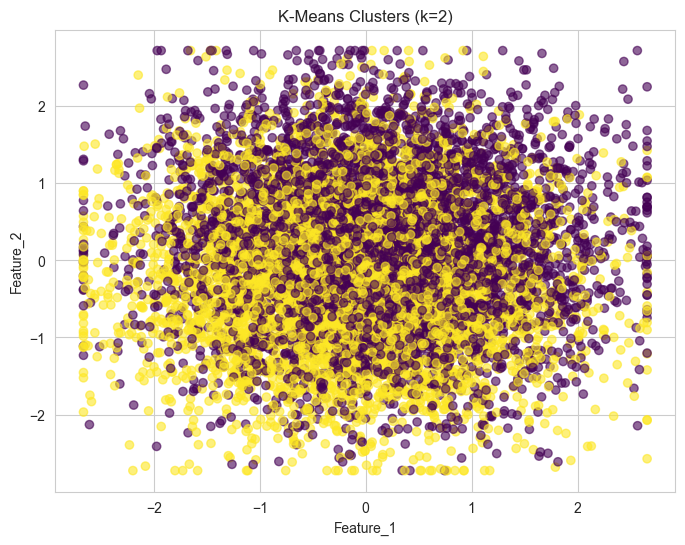

In [28]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_selected)

plt.figure(figsize=(8, 6))
plt.scatter(X_selected["Feature_1"], X_selected["Feature_2"], c=cluster_labels, cmap="viridis", alpha=0.6)
plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.title(f"K-Means Clusters (k={best_k})")
plt.show()

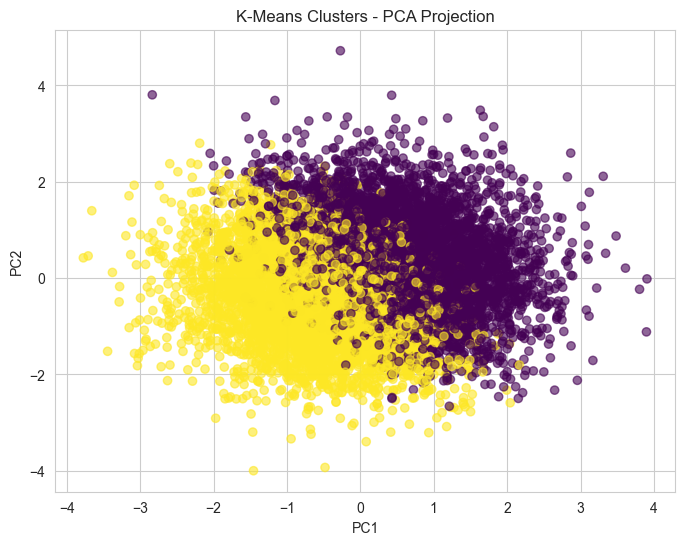

In [29]:
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_selected)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels, cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters - PCA Projection")
plt.show()

#### Discuss

**Optimal number of clusters:** determined above via the silhouette score peak (see `best_k`).

**Cluster characteristics:** since this dataset uses independent random features with no
injected latent groups, expect the silhouette scores to be modest and clusters to look
fairly arbitrary rather than tightly separated - this is itself a valid, honest finding
to report (no strong natural grouping exists in the raw feature space).

**Advantages:** K-Means is fast, scales well, simple to interpret.

**Limitations:** assumes spherical, similarly-sized clusters; sensitive to initial centroids
and outliers; requires specifying k upfront; struggles with non-convex cluster shapes.

### Supervised Learning (Classification)  
- Logistic Regression 
- Decision Tree Classifier 
- Random Forest Classifier 

In [30]:
# Derive Classification Target
y_class = pd.qcut(y, q=3, labels=["Low", "Medium", "High"])

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_selected, y_class, test_size=0.2, random_state=42, stratify=y_class
)
print("Class distribution:\n", y_class.value_counts())

Class distribution:
 Target
Low       3334
Medium    3333
High      3333
Name: count, dtype: int64


In [31]:
# Train - Test
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200),
}

clf_predictions = {}
clf_proba = {}
for name, model in clf_models.items():
    model.fit(X_train_c, y_train_c)
    clf_predictions[name] = model.predict(X_test_c)
    clf_proba[name] = model.predict_proba(X_test_c)

print("Models trained:", list(clf_models.keys()))

Models trained: ['Logistic Regression', 'Decision Tree', 'Random Forest']


In [33]:
# Evaluation - Accuracy, Precision, Recall, F1, ROC-AUC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

clf_results = []
for name, y_pred in clf_predictions.items():
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, average="weighted")
    rec = recall_score(y_test_c, y_pred, average="weighted")
    f1 = f1_score(y_test_c, y_pred, average="weighted")
    auc = roc_auc_score(y_test_c, clf_proba[name], multi_class="ovr", average="weighted")
    clf_results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": auc})

clf_results_df = pd.DataFrame(clf_results)
clf_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9050,0.905747,0.9050,0.905285,0.983434
1,Decision Tree,0.8035,0.801565,0.8035,0.802324,0.852638
2,Random Forest,0.8790,0.879906,0.8790,0.879348,0.971540


### Visualizations 


- Confusion Matrix 


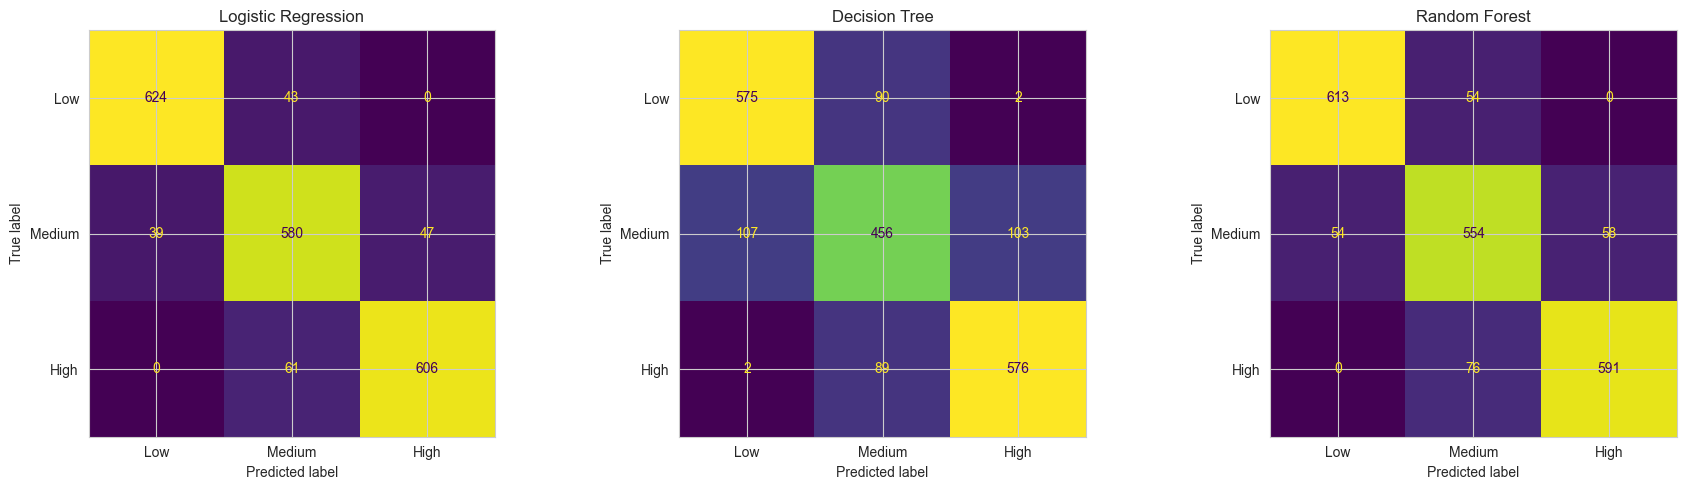

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, clf_predictions.items()):
    cm = confusion_matrix(y_test_c, y_pred, labels=["Low", "Medium", "High"])
    ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


- ROC Curve 


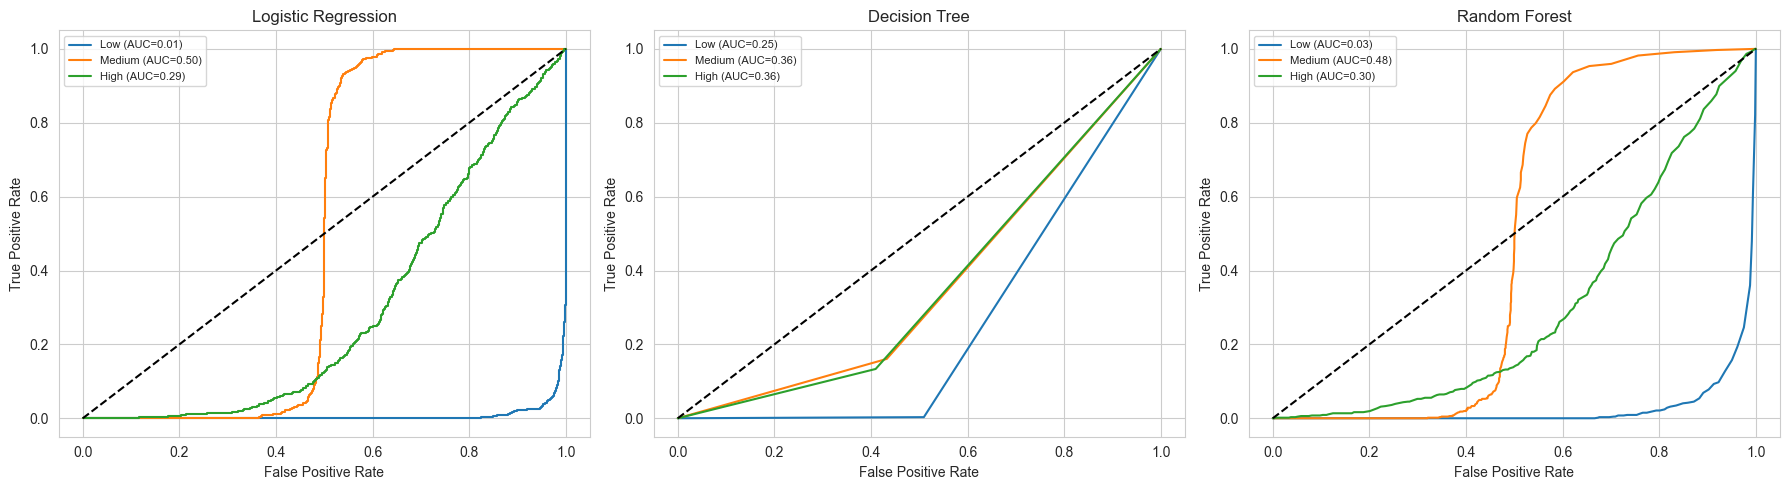

In [35]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test_c, classes=["Low", "Medium", "High"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, proba) in zip(axes, clf_proba.items()):
    for i, cls in enumerate(["Low", "Medium", "High"]):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.2f})")
    ax.plot([0, 1], [0, 1], "k--")
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


- Feature Importance

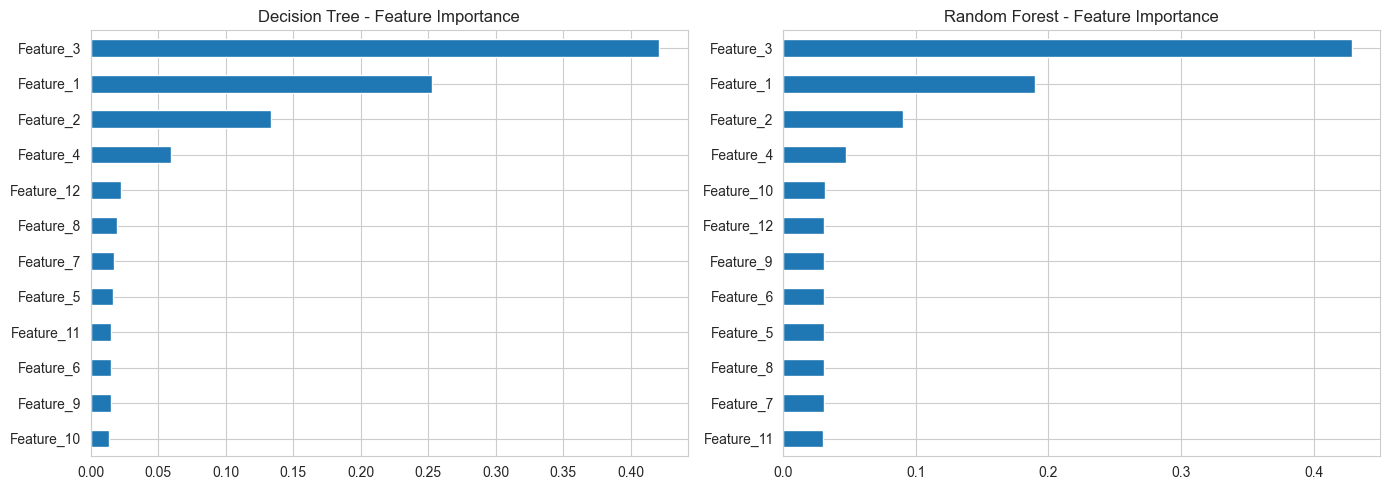

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, name in zip(axes, ["Decision Tree", "Random Forest"]):
    importances = pd.Series(clf_models[name].feature_importances_, index=X_selected.columns)
    importances.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"{name} - Feature Importance")
plt.tight_layout()
plt.show()

### Unsupervised Learning 
#### Hierarchical Clustering 

- Agglomerative Clustering 
- Dendrogram 
- Linkage Comparison

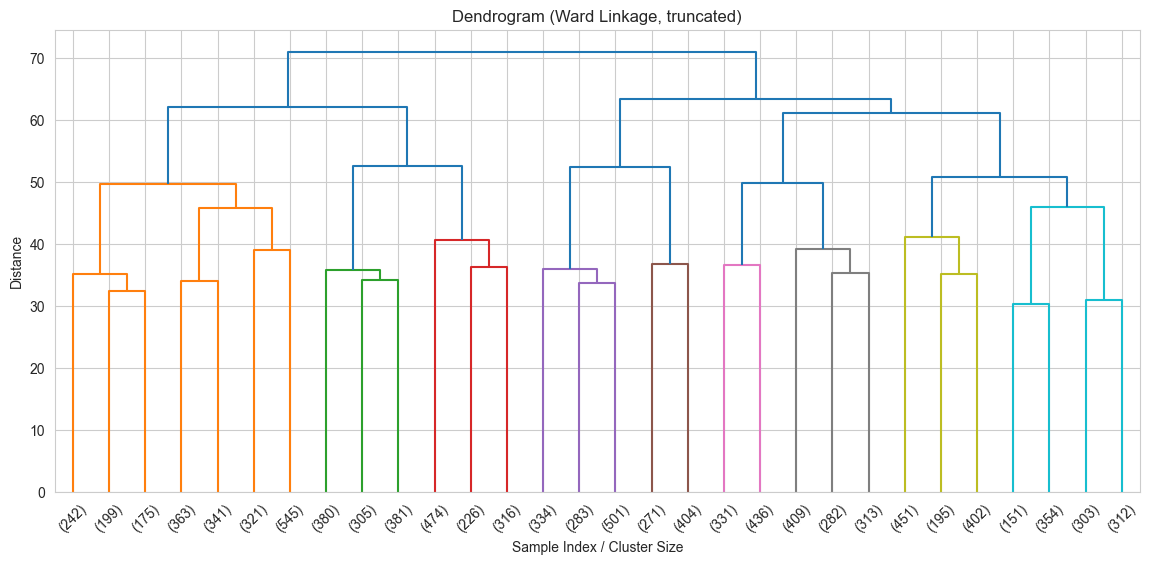

In [37]:
# Dendogram
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_selected, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Dendrogram (Ward Linkage, truncated)")
plt.xlabel("Sample Index / Cluster Size")
plt.ylabel("Distance")
plt.show()

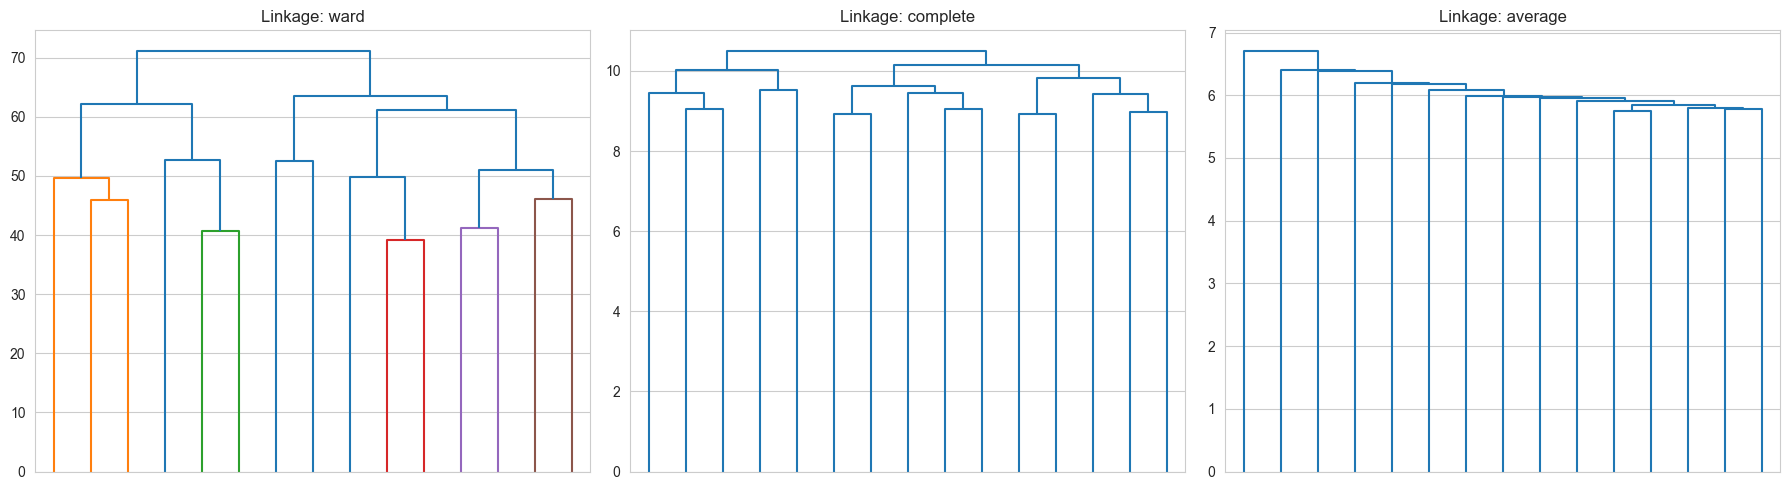

In [38]:
# Linkage Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, method in zip(axes, ["ward", "complete", "average"]):
    Z_method = linkage(X_selected, method=method)
    dendrogram(Z_method, truncate_mode="lastp", p=15, ax=ax, no_labels=True)
    ax.set_title(f"Linkage: {method}")
plt.tight_layout()
plt.show()

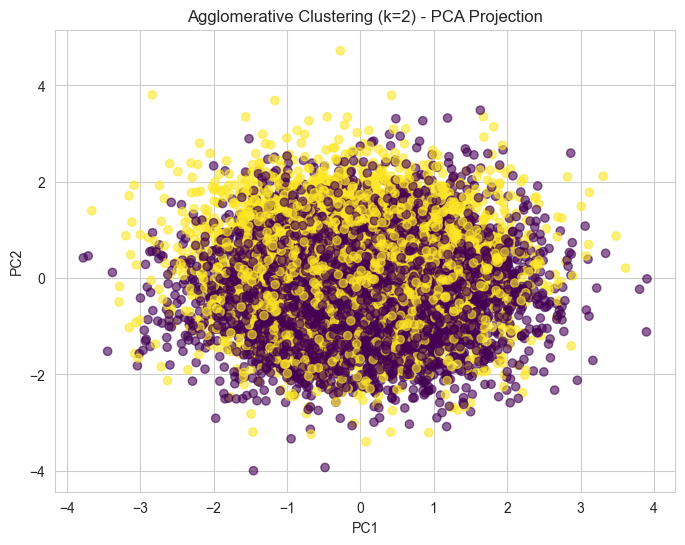

In [39]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
agglo_labels = agglo.fit_predict(X_selected)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=agglo_labels, cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Agglomerative Clustering (k={best_k}) - PCA Projection")
plt.show()

#### Discuss

**Cluster hierarchy:** the dendrogram shows how samples merge progressively - the height of
each merge represents the distance between clusters being joined; cutting the tree at a given
height yields a specific number of clusters.

**Interpretation:** compare the resulting cluster assignments against `cluster_labels` from
K-Means - large disagreement between the two suggests the underlying feature
space doesn't have strongly separated natural groups.

**Comparison with K-Means:** Hierarchical clustering doesn't require pre-specifying k upfront
(you can inspect the dendrogram and choose a cut), and it captures nested cluster structure -
but it's computationally heavier (O(n^2) or worse) and less scalable to large datasets than
K-Means.

### Supervised Learning 

- Support Vector Machine (SVM) 
- K-Nearest Neighbors (KNN) 
- Gradient Boosting Classifier

#### Hyperparameter tuning using GridSearchCV

In [41]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

param_grids = {
    "SVM": (
        CalibratedClassifierCV(SVC(random_state=42), ensemble=False), 
        {"estimator__C": [0.1, 1, 10], "estimator__kernel": ["rbf", "linear"]}
    ),
    "KNN": (
        KNeighborsClassifier(), 
        {"n_neighbors": [3, 5, 7, 9]}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42), 
        {"n_estimators": [100, 200], "learning_rate": [0.05, 0.1]}
    ),
}

best_models = {}
for name, (estimator, grid) in param_grids.items():
    gs = GridSearchCV(estimator, grid, cv=5, scoring="f1_weighted", n_jobs=-1)
    gs.fit(X_train_c, y_train_c)
    best_models[name] = gs.best_estimator_
    print(f"{name} best params: {gs.best_params_}")

SVM best params: {'estimator__C': 0.1, 'estimator__kernel': 'linear'}
KNN best params: {'n_neighbors': 9}
Gradient Boosting best params: {'learning_rate': 0.1, 'n_estimators': 200}


In [42]:
# Evaluation - Accuracy, Precision, Recall, F1
eng_predictions = {name: model.predict(X_test_c) for name, model in best_models.items()}

eng_results = []
for name, y_pred in eng_predictions.items():
    eng_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_c, y_pred),
        "Precision": precision_score(y_test_c, y_pred, average="weighted"),
        "Recall": recall_score(y_test_c, y_pred, average="weighted"),
        "F1": f1_score(y_test_c, y_pred, average="weighted"),
    })

eng3_results_df = pd.DataFrame(eng_results)
eng3_results_df

,Model,Accuracy,Precision,Recall,F1
0,SVM,0.9060,0.906541,0.9060,0.906214
1,KNN,0.7600,0.761102,0.7600,0.760378
2,Gradient Boosting,0.8915,0.893713,0.8915,0.892205


#### Visualizations 
- Decision Boundary (2D PCA Projection) 
- Confusion Matrix

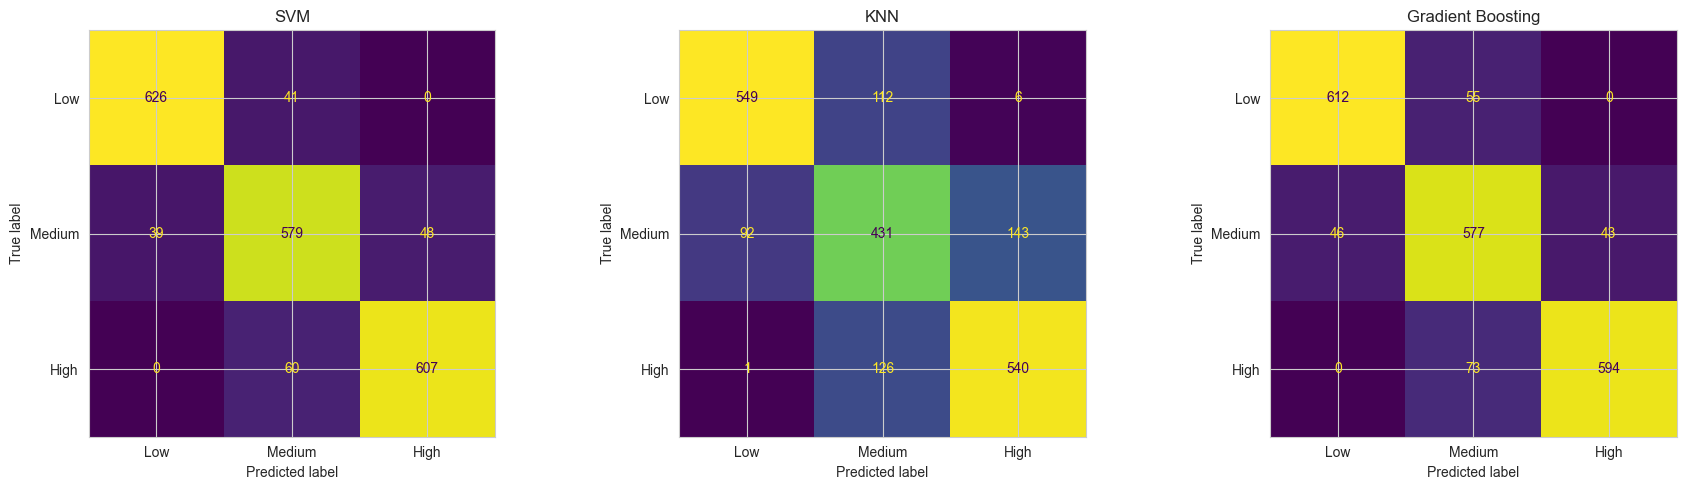

In [43]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, eng_predictions.items()):
    cm = confusion_matrix(y_test_c, y_pred, labels=["Low", "Medium", "High"])
    ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

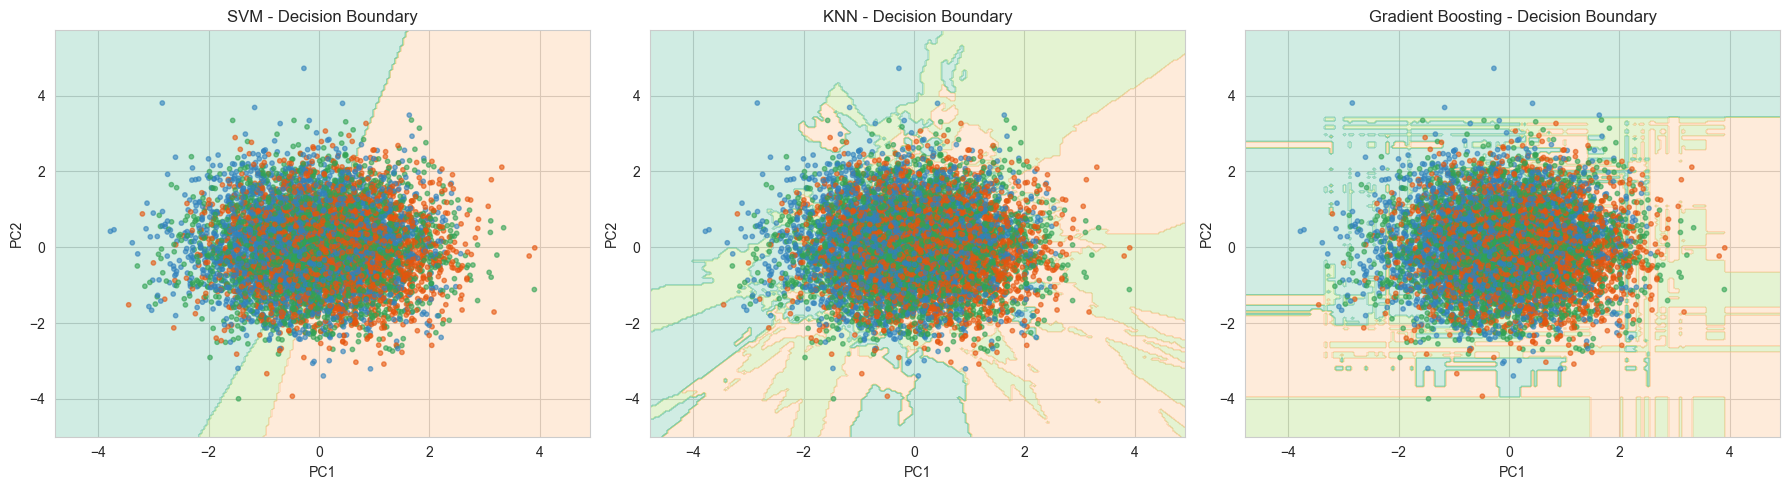

In [45]:
# Decision Boundary (2D PCA Projection) 
from sklearn.base import clone
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

X_train_pca = pca_2d.transform(X_train_c)
class_map = {"Low": 0, "Medium": 1, "High": 2}
y_train_num = y_train_c.map(class_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
xx, yy = np.meshgrid(
    np.linspace(X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1, 200),
    np.linspace(X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1, 200),
)

for ax, (name, model) in zip(axes, best_models.items()):
    boundary_model = clone(model)
    boundary_model.fit(X_train_pca, y_train_num)
    
    Z = boundary_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(["#FDBE85", "#A6D96A", "#66C2A5"]))
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_num, cmap=ListedColormap(["#E6550D", "#31A354", "#3182BD"]), s=10, alpha=0.6)
    ax.set_title(f"{name} - Decision Boundary")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

### DBSCAN 

- Parameter tuning 
- Cluster visualization 
- Noise point analysis

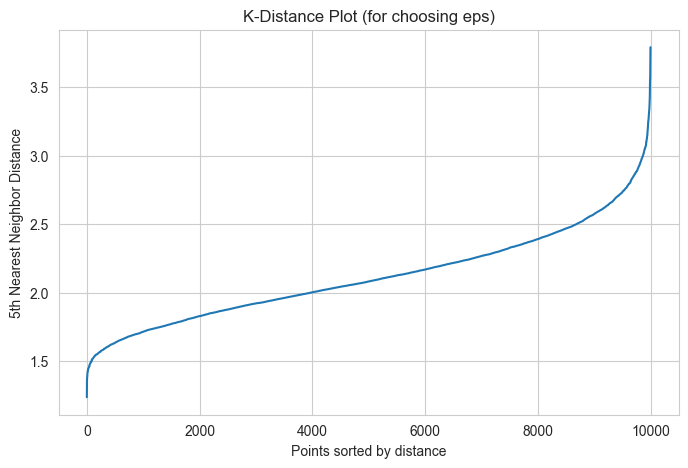

In [46]:
# Paramter tuning
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# k-distance plot to help choose eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_selected)
distances, _ = neighbors_fit.kneighbors(X_selected)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot (for choosing eps)")
plt.grid(True)
plt.show()

In [47]:
# Trying a small grid of eps/min_samples combinations
dbscan_results = []
for eps in [0.5, 1.0, 1.5, 2.0]:
    for min_samples in [5, 10, 15]:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_selected)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        dbscan_results.append({"eps": eps, "min_samples": min_samples, "clusters": n_clusters, "noise_points": n_noise})

pd.DataFrame(dbscan_results)

,eps,min_samples,clusters,noise_points
0,0.5,5,0,10000
1,0.5,10,0,10000
2,0.5,15,0,10000
3,1.0,5,0,10000
4,1.0,10,0,10000
5,1.0,15,0,10000
6,1.5,5,27,9700
7,1.5,10,0,10000
8,1.5,15,0,10000
9,2.0,5,7,3688


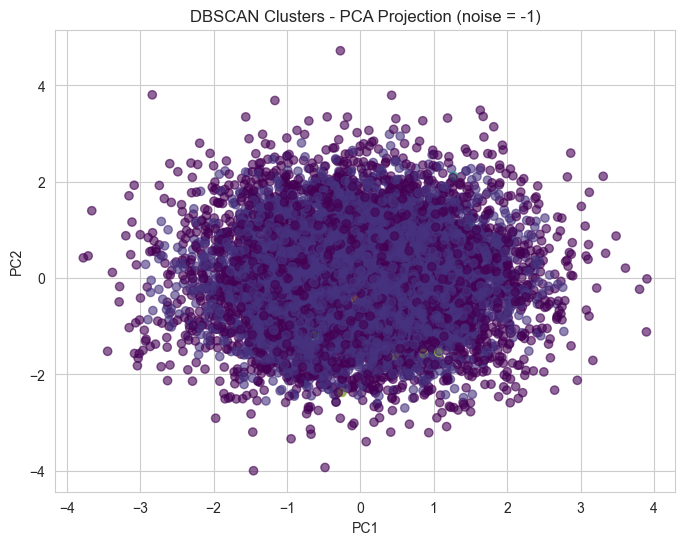

Clusters found: 7
Noise points: 3688


In [48]:
# Cluster visualization
dbscan_final = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan_final.fit_predict(X_selected)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=dbscan_labels, cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters - PCA Projection (noise = -1)")
plt.show()

print("Clusters found:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Noise points:", list(dbscan_labels).count(-1))

In [49]:
# Noise point analysis 
noise_pct = (list(dbscan_labels).count(-1) / len(dbscan_labels)) * 100
print(f"Noise points: {list(dbscan_labels).count(-1)} ({noise_pct:.1f}% of dataset)")

# Compare feature statistics: noise points vs clustered points
X_selected["_dbscan_label"] = dbscan_labels
comparison = X_selected.groupby(X_selected["_dbscan_label"] == -1).mean()
X_selected.drop(columns="_dbscan_label", inplace=True)
comparison.index = ["Clustered", "Noise"]
comparison

Noise points: 3688 (36.9% of dataset)


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Feature_11,Feature_12,_dbscan_label
Clustered,-0.003145,0.003392,-0.017270,-0.014497,0.006843,-0.007044,0.007263,0.008772,0.020554,-0.022148,0.001536,0.003515,0.010615
Noise,0.005382,-0.005805,0.029557,0.024811,-0.011712,0.012055,-0.012430,-0.015013,-0.035179,0.037906,-0.002629,-0.006016,-1.000000


#### Discuss

**Density-based clustering:** DBSCAN groups points that are closely packed together (dense
regions) and marks points in low-density regions as noise (`-1` label), rather than forcing
every point into a cluster.

**Comparison with centroid-based clustering (K-Means):** K-Means assumes spherical clusters
of similar size and forces every point into exactly one cluster. DBSCAN can find arbitrarily
shaped clusters and explicitly separates outliers/noise instead of dragging them into a
nearest centroid.

**Advantages over K-Means:** no need to specify the number of clusters upfront, robust to
outliers, works well with non-convex cluster shapes. **Trade-off:** more sensitive to the
`eps`/`min_samples` parameters, struggles with clusters of varying density.

### Supervised Learning 

- AdaBoost 
- Extra Trees Classifier 
- HistGradientBoosting Classifier

In [51]:
# Train models
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

en_models = {
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42, n_estimators=200),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
}

for name, model in en_models.items():
    model.fit(X_train_c, y_train_c)

print("Models trained:", list(en_models.keys()))

Models trained: ['AdaBoost', 'Extra Trees', 'HistGradientBoosting']


#### Perform 
- 5-Fold Cross Validation 
- Learning Curve 
- Performance Comparison

Metrics 
- Accuracy 
- Mean Cross Validation Score 
- Standard Deviation

In [53]:
# 5-Fold Cross Validation
from sklearn.model_selection import cross_val_score

cv_results = []
for name, model in en_models.items():
    scores = cross_val_score(model, X_selected, y_class, cv=5, scoring="accuracy")
    cv_results.append({
        "Model": name,
        "Mean CV Accuracy": scores.mean(),
        "Std Dev": scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,Mean CV Accuracy,Std Dev
0,AdaBoost,0.7990,0.014629
1,Extra Trees,0.8812,0.011990
2,HistGradientBoosting,0.8835,0.012157


In [54]:
# Test Set Accuracy (for comparison)
en_test_acc = {name: accuracy_score(y_test_c, model.predict(X_test_c)) for name, model in en_models.items()}
pd.Series(en_test_acc, name="Test Accuracy").sort_values(ascending=False)

HistGradientBoosting    0.8905
Extra Trees             0.8870
AdaBoost                0.7930
Name: Test Accuracy, dtype: float64

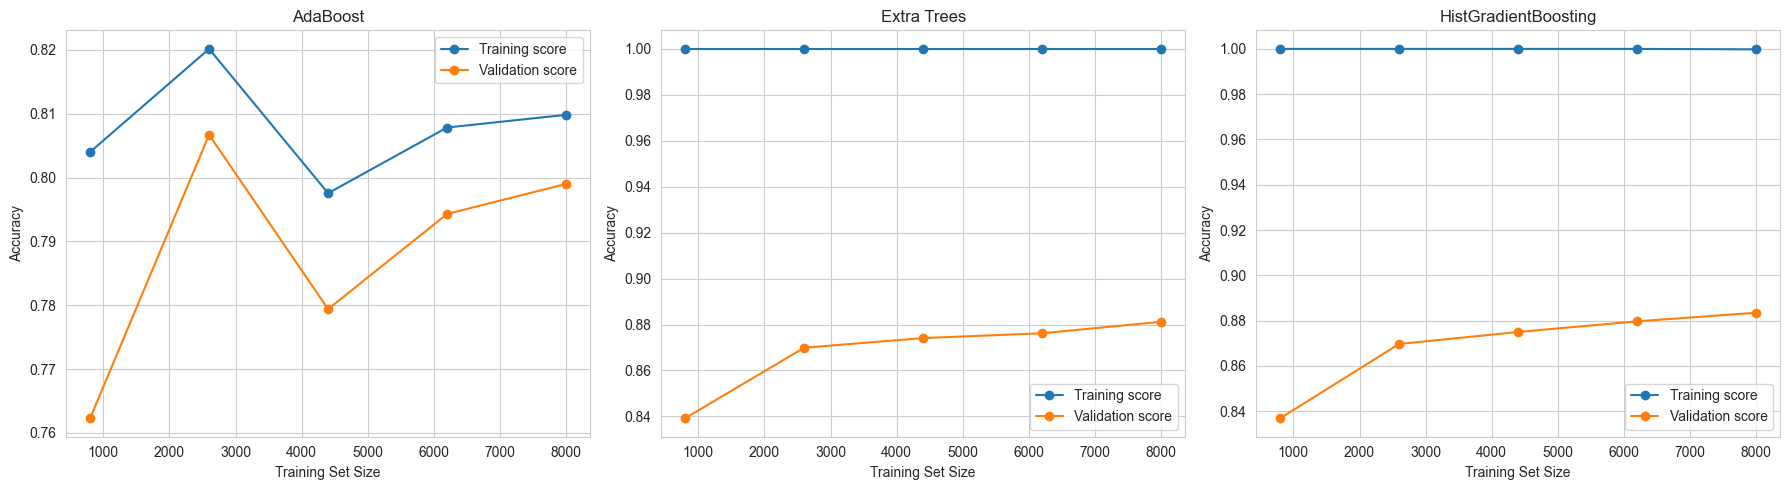

In [55]:
# Learning Curve 
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, en_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_selected, y_class, cv=5, scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training score")
    ax.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation score")
    ax.set_title(name)
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Accuracy")
    ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# Performance Comparison
summary = cv_results_df.merge(
    pd.Series(en_test_acc, name="Test Accuracy").reset_index().rename(columns={"index": "Model"}),
    on="Model"
)
summary

,Model,Mean CV Accuracy,Std Dev,Test Accuracy
0,AdaBoost,0.7990,0.014629,0.7930
1,Extra Trees,0.8812,0.011990,0.8870
2,HistGradientBoosting,0.8835,0.012157,0.8905


### Unsupervised Learning 
#### Gaussian Mixture Model (GMM) 

- Soft Clustering 
- Cluster Probability Estimation

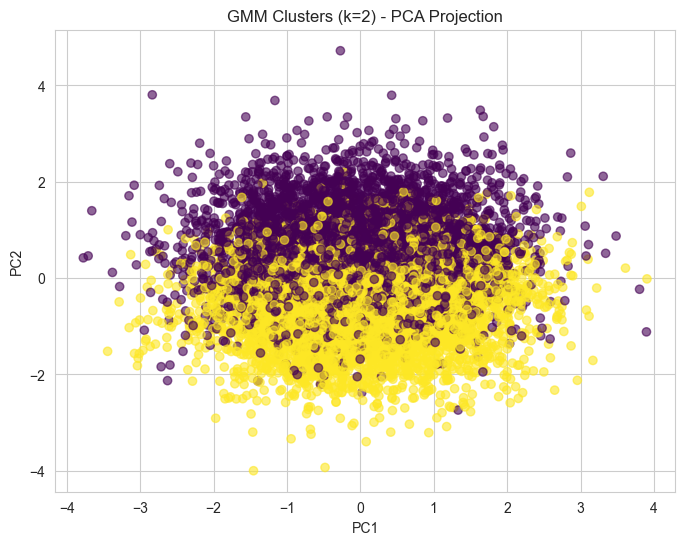

In [57]:
# Soft Clustering
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=best_k, random_state=42)
gmm_labels = gmm.fit_predict(X_selected)
gmm_proba = gmm.predict_proba(X_selected)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=gmm_labels, cmap="viridis", alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM Clusters (k={best_k}) - PCA Projection")
plt.show()

In [58]:
# Cluster Probability Estimation
proba_df = pd.DataFrame(gmm_proba, columns=[f"Cluster_{i}_prob" for i in range(best_k)])
proba_df["assigned_cluster"] = gmm_labels
proba_df["max_confidence"] = gmm_proba.max(axis=1)
proba_df.head(10)

,Cluster_0_prob,Cluster_1_prob,assigned_cluster,max_confidence
0,0.874651,0.125349,0,0.874651
1,0.831918,0.168082,0,0.831918
2,0.309073,0.690927,1,0.690927
3,0.717499,0.282501,0,0.717499
4,0.959490,0.040510,0,0.959490
5,0.850352,0.149648,0,0.850352
6,0.806393,0.193607,0,0.806393
7,0.967578,0.032422,0,0.967578
8,0.543075,0.456925,0,0.543075
9,0.122443,0.877557,1,0.877557


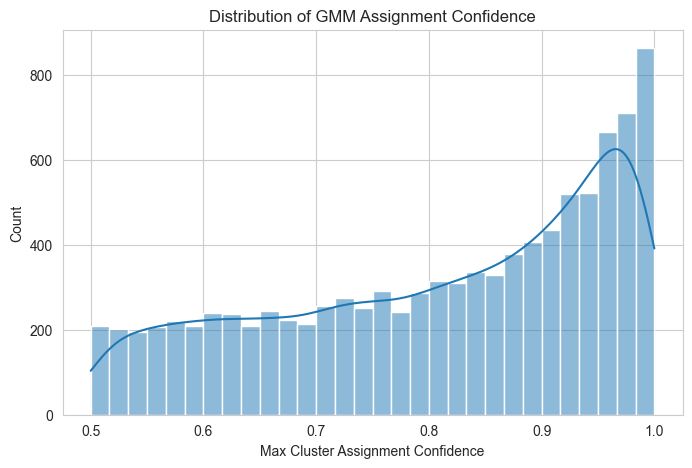

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(proba_df["max_confidence"], bins=30, kde=True)
plt.xlabel("Max Cluster Assignment Confidence")
plt.title("Distribution of GMM Assignment Confidence")
plt.show()

#### Compare

**GMM vs K-Means:** K-Means assigns each point to exactly one cluster based on nearest
centroid (hard boundary, spherical assumption). GMM models each cluster as a Gaussian
distribution with its own mean and covariance, allowing elliptical cluster shapes and
capturing more nuanced structure.

**Hard vs Soft Clustering:** K-Means is hard clustering - every point gets a single, binary
cluster label. GMM is soft clustering - every point gets a probability of belonging to each
cluster (see `max_confidence` above). Points near cluster boundaries will show low max
confidence, correctly reflecting real ambiguity that K-Means would hide.

## Model Comparison Table

In [60]:
import time

# Re-time each model's training for a fair comparison across all engineers
comparison_rows = []

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    comparison_rows.append({"Model": f"[Regression] {name}", "Score (R2)": r2_score(y_test, model.predict(X_test)), "Training Time (s)": train_time})

all_clf_models = {**clf_models, **best_models, **en_models}
for name, model in all_clf_models.items():
    t0 = time.time()
    model.fit(X_train_c, y_train_c)
    train_time = time.time() - t0
    comparison_rows.append({"Model": f"[Classification] {name}", "Score (Accuracy)": accuracy_score(y_test_c, model.predict(X_test_c)), "Training Time (s)": train_time})

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Score (R2),Training Time (s),Score (Accuracy)
0,[Regression] Linear Regression,0.972319,0.044424,NaN
1,[Regression] Decision Tree,0.901014,0.095385,NaN
2,[Regression] Random Forest,0.957024,8.752036,NaN
3,[Classification] Logistic Regression,NaN,0.077231,0.9050
4,[Classification] Decision Tree,NaN,0.079924,0.8035
5,[Classification] Random Forest,NaN,3.274560,0.8790
6,[Classification] SVM,NaN,1.905260,0.9060
7,[Classification] KNN,NaN,0.025301,0.7600
8,[Classification] Gradient Boosting,NaN,14.365670,0.8915
9,[Classification] AdaBoost,NaN,0.822482,0.7930
